In [5]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt


sns.set(style="whitegrid", context="talk")
# plt.rcParams["font.family"] = "Arial"

In [6]:

CELL2SPACE_DIR = Path("/home/guanqiyuan/Cell2space/Cell2space/Cell2sapce_script")
if str(CELL2SPACE_DIR) not in sys.path:
    sys.path.insert(0, str(CELL2SPACE_DIR))

from cell2space_runner import DLPFC_LAYER_RELATIONS, evaluate_cell2space_result, run_cell2space



SC_PATH = Path("/storage/guanqiyuan/Dataset(multi)/DLPFC/151509.h5ad")
ST_PATH = Path("/storage/guanqiyuan/Dataset(multi)/DLPFC/151510.h5ad")
OUT_DIR = Path("/home/guanqiyuan/Cell2space/tutorial_DLPFC_151509_to_151510")
OUT_DIR.mkdir(exist_ok=True, parents=True)

DOMAIN_COL = "Region"
SPATIAL_COLS = ("array_row", "array_col")

BASE_CONFIG = {
    "sc_path": str(SC_PATH),
    "st_path": str(ST_PATH),
    "domain_col": DOMAIN_COL,
    "sc_spatial_cols": SPATIAL_COLS,
    "st_spatial_cols": SPATIAL_COLS,
    "device": "cuda",
    "seed": 42,
    "select_hvg": "union",
    "n_features": 1000,
    "use_harmony": True,
    "k_neighbors": 3,
    "total_pos": 15000,
    "total_neg": 45000,
    "epochs": 300,
    "batch_size": 256,
    "filter_mode": "hard",
    "soft_alpha": 0.1,
    "layer_relations": "auto",
}

In [7]:

adata_sc_raw = sc.read_h5ad(SC_PATH)
adata_st_raw = sc.read_h5ad(ST_PATH)

print("Query slice 151509")
print(adata_sc_raw)
print(adata_sc_raw.obs.head())

print("\nReference slice 151510")
print(adata_st_raw)
print(adata_st_raw.obs.head())

print("\nQuery domain counts")
print(adata_sc_raw.obs[DOMAIN_COL].value_counts(dropna=False))

print("\nReference domain counts")
print(adata_st_raw.obs[DOMAIN_COL].value_counts(dropna=False))

Query slice 151509
AnnData object with n_obs × n_vars = 4789 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'Region', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'moranI', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'
                    in_tissue  array_row  array_col  Region leiden
AAACAAGTATCTCCCA-1          1         50        102  Layer1      4
AAACAATCTACTAGCA-1          1          3         43  Layer3      0
AAACACCAATAACTGC-1          1         59         19  Layer6      1
AAACAGAGCGACTCCT-1          1         14         94  Layer3      0
AAACAGCTTTCAGAAG-1          1         43          9  Layer4      6

Reference slice 151510
AnnData object with n_obs × n_vars = 4634 × 33538
    obs: 'in_ti

In [8]:
def check_required_fields(adata_obj, name, domain_col, spatial_cols):
    missing = []
    if domain_col not in adata_obj.obs.columns:
        missing.append(domain_col)
    for col in spatial_cols:
        if col not in adata_obj.obs.columns:
            missing.append(col)
    if missing:
        raise KeyError(f"{name} missing required columns: {missing}")
    print(f"{name}: OK")


check_required_fields(adata_sc_raw, "Query 151509", DOMAIN_COL, SPATIAL_COLS)
check_required_fields(adata_st_raw, "Reference 151510", DOMAIN_COL, SPATIAL_COLS)


Query 151509: OK
Reference 151510: OK


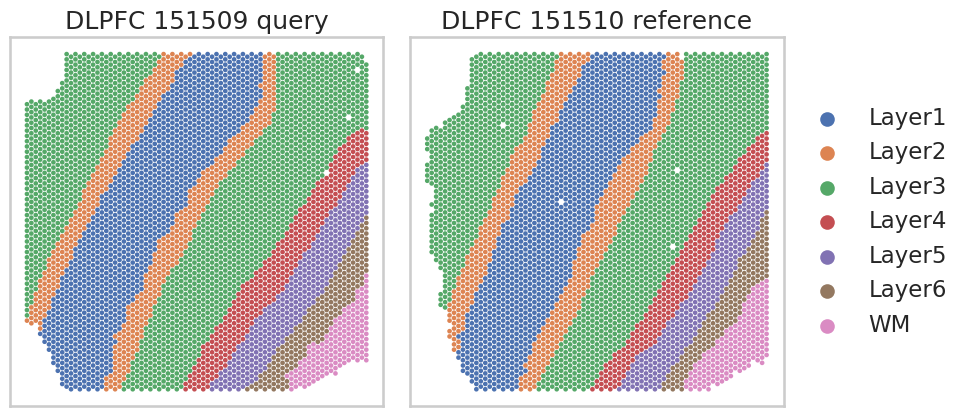

In [9]:
adata_sc_preview = adata_sc_raw[~adata_sc_raw.obs[DOMAIN_COL].isna()].copy()
adata_st_preview = adata_st_raw[~adata_st_raw.obs[DOMAIN_COL].isna()].copy()

adata_sc_preview.obsm["spatial"] = adata_sc_preview.obs[list(SPATIAL_COLS)].to_numpy(dtype=float)
adata_st_preview.obsm["spatial"] = adata_st_preview.obs[list(SPATIAL_COLS)].to_numpy(dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), facecolor="white")

sc.pl.embedding(
    adata_sc_preview,
    basis="spatial",
    color=DOMAIN_COL,
    ax=axes[0],
    show=False,
    title="DLPFC 151509 query",
    legend_loc=None,
    size=45,
)

sc.pl.embedding(
    adata_st_preview,
    basis="spatial",
    color=DOMAIN_COL,
    ax=axes[1],
    show=False,
    title="DLPFC 151510 reference",
    legend_loc="right margin",
    size=45,
)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [10]:
result_full = run_cell2space(
    **BASE_CONFIG,
    mode="full",
    out_dir=str(OUT_DIR / "full"),
    save_outputs=True,
    save_dense_outputs=True,
)



Number of common genes selected: 1630
Starting Harmony integration...
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
Reach convergence after 3 iteration(s).
Harmony integration done. Time: 0:01:25.354991
Epoch 0, Loss: 0.4796
Epoch 50, Loss: 0.0032
Epoch 100, Loss: 0.0018
Epoch 150, Loss: 0.0009
Epoch 200, Loss: 0.0006
Epoch 250, Loss: 0.0001


Predicting Cell-Spot relationships: 100%|██████████| 4789/4789 [00:02<00:00, 1730.63it/s]


Predicted domain counts:
{'Layer1': 1346, 'Layer2': 639, 'Layer3': 1692, 'Layer4': 192, 'Layer5': 420, 'Layer6': 302, 'WM': 198}


Computing Cell-Cell relations: 100%|██████████| 4789/4789 [00:23<00:00, 202.29it/s]


In [15]:
print("Full mode finished")
print("Inference outputs:")
print("SC-ST matrix:", result_full["sc_st_matrix"].shape)
print("SC domain scores:", result_full["sc_domain_scores"].shape)
print("SC-SC matrix:", result_full["sc_sc_matrix"].shape)

Full mode finished
Inference outputs:
SC-ST matrix: (4595, 4789)
SC domain scores: (4789, 7)
SC-SC matrix: (4789, 4789)


In [23]:
pred_domains = np.asarray(result_full["sc_domain_predictions"]).astype(str)

print("Predicted domain labels:")
print(pred_domains)

print("\nPredicted domain counts:")
print(pd.Series(pred_domains).value_counts().sort_index())

adata_sc = result_full["adata_sc"]

if "domain" in adata_sc.obs.columns:
    true_domains = adata_sc.obs["domain"].astype(str).values
else:
    true_domains = adata_sc.obs[DOMAIN_COL].astype(str).values

acc = np.mean(pred_domains == true_domains)

print("Domain accuracy:", acc)



Predicted domain labels:
['Layer1' 'Layer2' 'Layer5' ... 'Layer4' 'Layer1' 'Layer3']

Predicted domain counts:
Layer1    1346
Layer2     639
Layer3    1692
Layer4     192
Layer5     420
Layer6     302
WM         198
Name: count, dtype: int64
Domain accuracy: 0.7051576529546878


In [25]:
metrics_full = evaluate_cell2space_result(result_full, evaluate_k=(1, 3, 5, 10, 15))

metrics_full["cosine_k5"]

Calculating distances: 100%|██████████| 4789/4789 [00:30<00:00, 159.56it/s]


0.9241625666618347

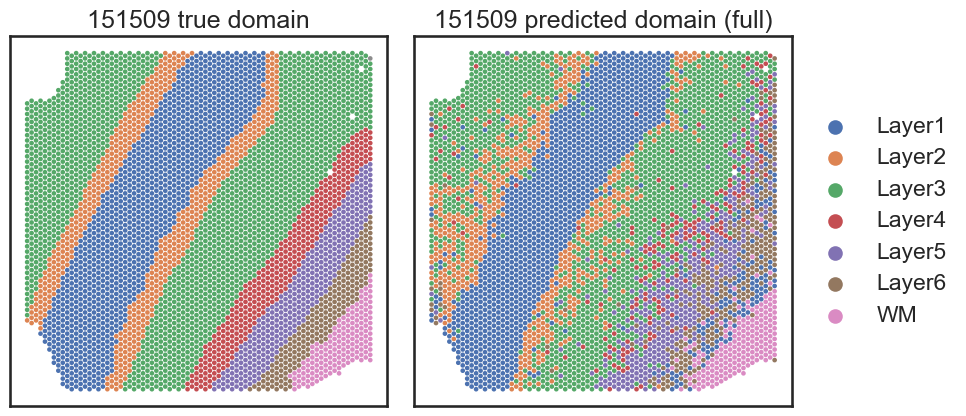

In [19]:
adata_full = result_full["adata_sc"].copy()
adata_full.obs["predicted_domain"] = np.asarray(result_full["predicted_domains"]).astype(str)

# inference-only 模式下不一定有 obs["domain"]
# DLPFC 真实标签通常还在 obs["Region"] 里
if "domain" not in adata_full.obs.columns:
    if DOMAIN_COL in adata_full.obs.columns:
        adata_full.obs["domain"] = adata_full.obs[DOMAIN_COL].astype(str)
    else:
        raise KeyError("No true domain labels found. Cannot plot true domain.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), facecolor="white")


sc.pl.embedding(
    adata_full,
    basis="spatial",
    color="domain",
    ax=axes[0],
    show=False,
    title="151509 true domain",
    legend_loc=None,
    size=45,
)

sc.pl.embedding(
    adata_full,
    basis="spatial",
    color="predicted_domain",
    ax=axes[1],
    show=False,
    title="151509 predicted domain (full)",
    legend_loc="right margin",
    size=45,
)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()